In [91]:
import pandas as pd
import plotnine as p9
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Section 01 - Adjusting for confounding variables - Yeast QTL
Recall the yeast dataset from the previous exercises and lecture, which analyses the genetic determinants
of yeast growth rates. We look at three genes, for simplicity called A, B and C, of which each yeast can
have one of two variants: “wild” or “lab”. We want to determine whether the different variants of these
genes are associated with differences in growth rate. In particular, we consider once again the question:
Does the gene-B variant still associate with growth when conditioned on the gene-A variant?

In [92]:
growth_analysis = (pd.read_csv("../EX7/growth_analysis.txt", sep = '\t')
.rename(columns = {'gene_5211': 'gene_A',
'gene_5091': 'gene_B',
'gene_1653': 'gene_C'})
.loc[:, ['strain', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']])
growth_analysis.head()

,strain,growth_rate,gene_A,gene_B,gene_C
0,seg_01B,6.720447,False,False,True
1,seg_01C,7.429273,False,False,True
2,seg_01D,6.905589,True,True,False
3,seg_02B,4.924324,False,True,False
4,seg_02C,4.413402,False,False,True


/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


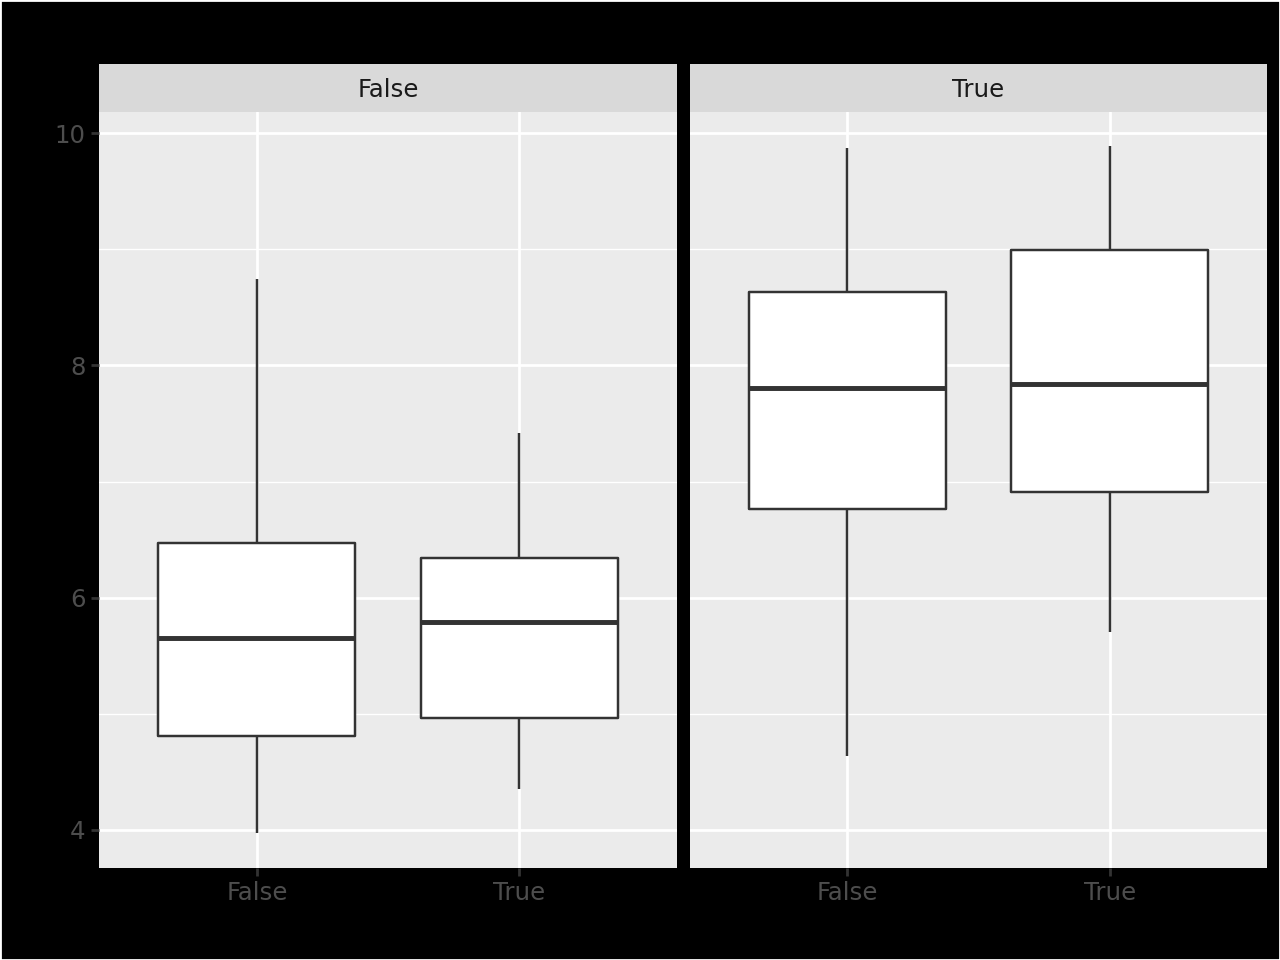

In [93]:
from plotnine import *

growth_analysis['gene_A'] = pd.Categorical(growth_analysis['gene_A'])

(ggplot(growth_analysis, aes('gene_B', 'growth_rate')) +
 geom_boxplot() +
 facet_wrap('gene_A') +
 xlab(f"Genotype at gene_B") +
 ylab("Growth rate in Maltose [Generations/day]") +
 labs(title = "Conditioned on gene_A"))


1. Run a linear model predicting the growth given the genotypes of both markers and interpret the result.
Call this model full. Observe that the distribution of the residuals mildly deviate from a Gaussian. We
will not worry for this. Using summary() comment on the full model fit and conclude.

In [94]:
# H0 - The markers do not affect the growth rate

full = smf.ols("growth_rate ~ gene_A + gene_B", data=growth_analysis).fit()
residuals = full.resid
full.summary()

# We find that gene B p value is > 0.38, which means that the result is insignificant when conditioned on gene A

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            growth_rate   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     58.29
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           1.74e-19
Time:                        16:55:18   Log-Likelihood:                -241.38
No. Observations:                 154   AIC:                             488.8
Df Residuals:                     151   BIC:                             497.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          5.7064      0.151     37.809      0.000       5.408       6.005
gene_A[T.True]     1.9743      0.201      9.834      0.000       1.578       2.371
gene_B[T.True]     0.1747      0.201      0.871      0.385      -0.222       0.571
==============================================================================
Omnibus:                        1.432   Durbin-Watson:                   1.916
Prob(Omnibus):                  0.489   Jarque-Bera (JB):                1.282
Skew:                           0.069   Prob(JB):                        0.527
Kurtosis:                       2.575   Cond. No.                         3.16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

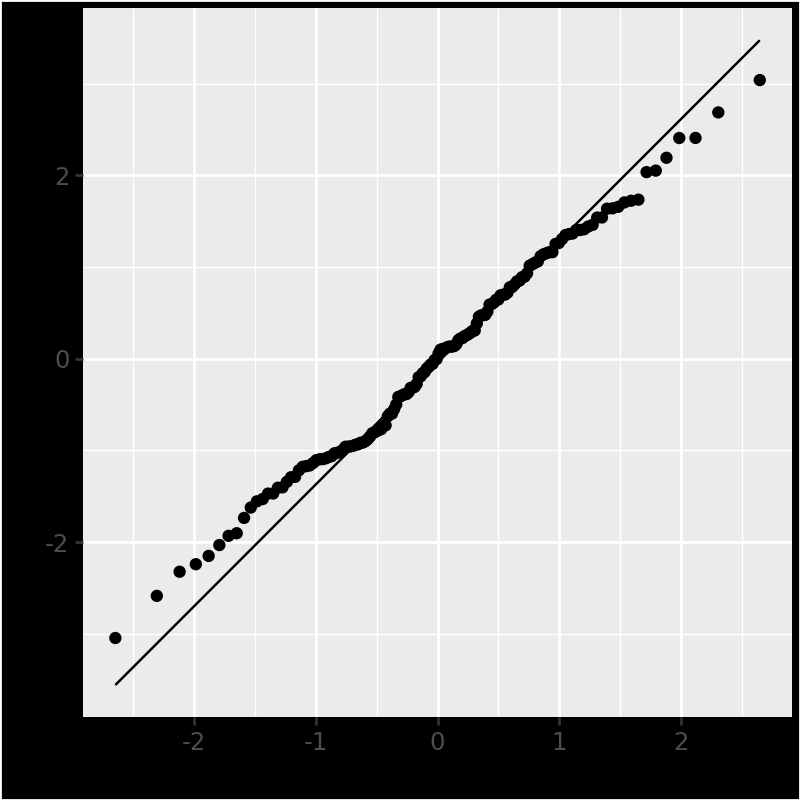

In [95]:
df_resid = pd.DataFrame({'resid': residuals})
(
    ggplot(df_resid, aes(sample="resid"))
    + stat_qq()
    + stat_qq_line()
    + theme(figure_size=(4, 4))
) # The errors do follow a normal distribution, so all good.

2. Create a reduced model that only depends on the genotype of gene_A. Check with a qqplot of that
the Gaussan assumptions roughly hold. Then run ANOVA to compare the full and the reduced model.
Is this analysis consistent with the one made in 1?

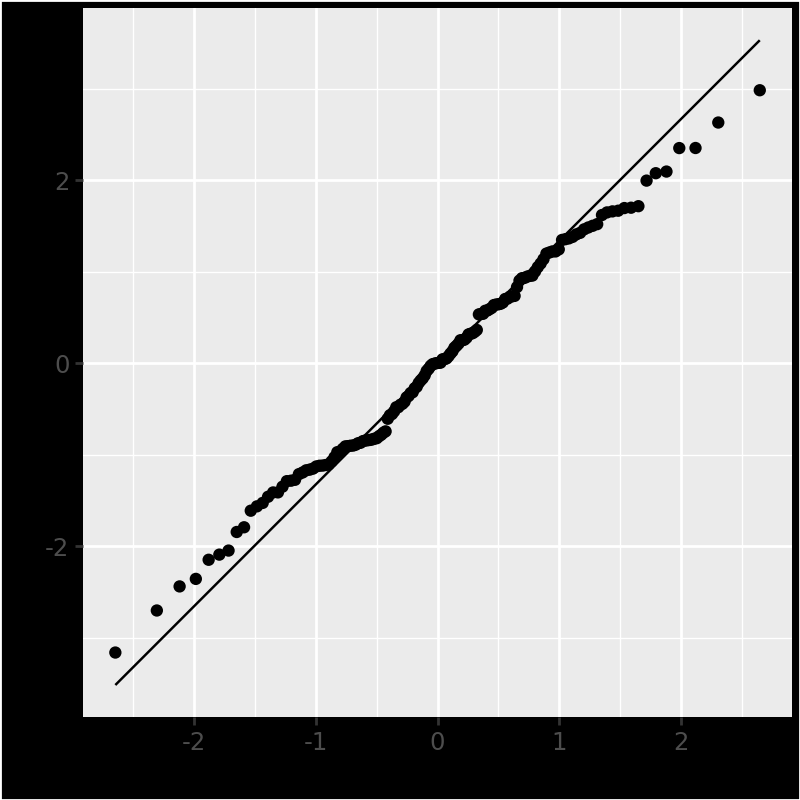

In [96]:
reduced = smf.ols("growth_rate ~ gene_A", data=growth_analysis).fit()
residuals_reduced = reduced.resid
df_resid = pd.DataFrame({'resid': residuals_reduced})
(
ggplot(df_resid, aes(sample="resid"))
+ stat_qq()
+ stat_qq_line()
+ theme(figure_size=(4, 4))
)

# Now running ANOVA analysis; our null hypothesis is:
# Ho: adding the genotype information of gene_B does not improve the model.

In [97]:
from statsmodels.stats.anova import anova_lm
anova_results = anova_lm(reduced, full)
print(anova_results)
# The probability under the null hypothesis of an F statistic as extreme as the one observed is high > 0.05 so we would not reject the null hypothesis

   df_resid         ssr  df_diff   ss_diff         F    Pr(>F)
0     152.0  208.275376      0.0       NaN       NaN       NaN
1     151.0  207.233953      1.0  1.041423  0.758827  0.385079


## Section 02 - Non-linearity
Load the “lm_nonlin.txt” dataset with the following code, adapted to your local folder. We find that y
correlates with x and z, but that x also correlates with z. We will investigate whether y is statistically
independent of z given x.

In [98]:
df = pd.read_csv("lm_nonlin.txt", sep = "\t")
df.head()
# df.corr()

,x,y,z
0,1.252117,5.772922,0.704380
1,0.254841,1.019366,0.552330
2,1.847125,18.740481,1.347555
3,-0.248480,8.478449,0.937754
4,2.204449,38.509134,1.978237


1. First address this question with an appropriate linear regression but without performing any diagnostic
plot. Which regression do you perform? What does this analysis indicate?
Multivariate linear regression
We regress (y independent of z) | x. we regress y against z and x.

In [99]:
fit = smf.ols("y ~ x + z", data=df).fit()
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     7251.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:55:19   Log-Likelihood:                -2528.4
No. Observations:                1000   AIC:                             5063.
Df Residuals:                     997   BIC:                             5077.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.9432      0.198    -29.980      0.000      -6.332      -5.554
x              0.7806      0.092      8.508      0.000       0.601       0.961
z             18.2867      0.246     74.331      0.000      17.804      18.769
==============================================================================
Omnibus:                       71.210   Durbin-Watson:                   2.080
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               52.823
Skew:                           0.462   Prob(JB):                     3.38e-12
Kurtosis:                       2.358   Cond. No.                         7.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

2. Perform relevant diagnostic plots. Is there any assumption violated?


/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


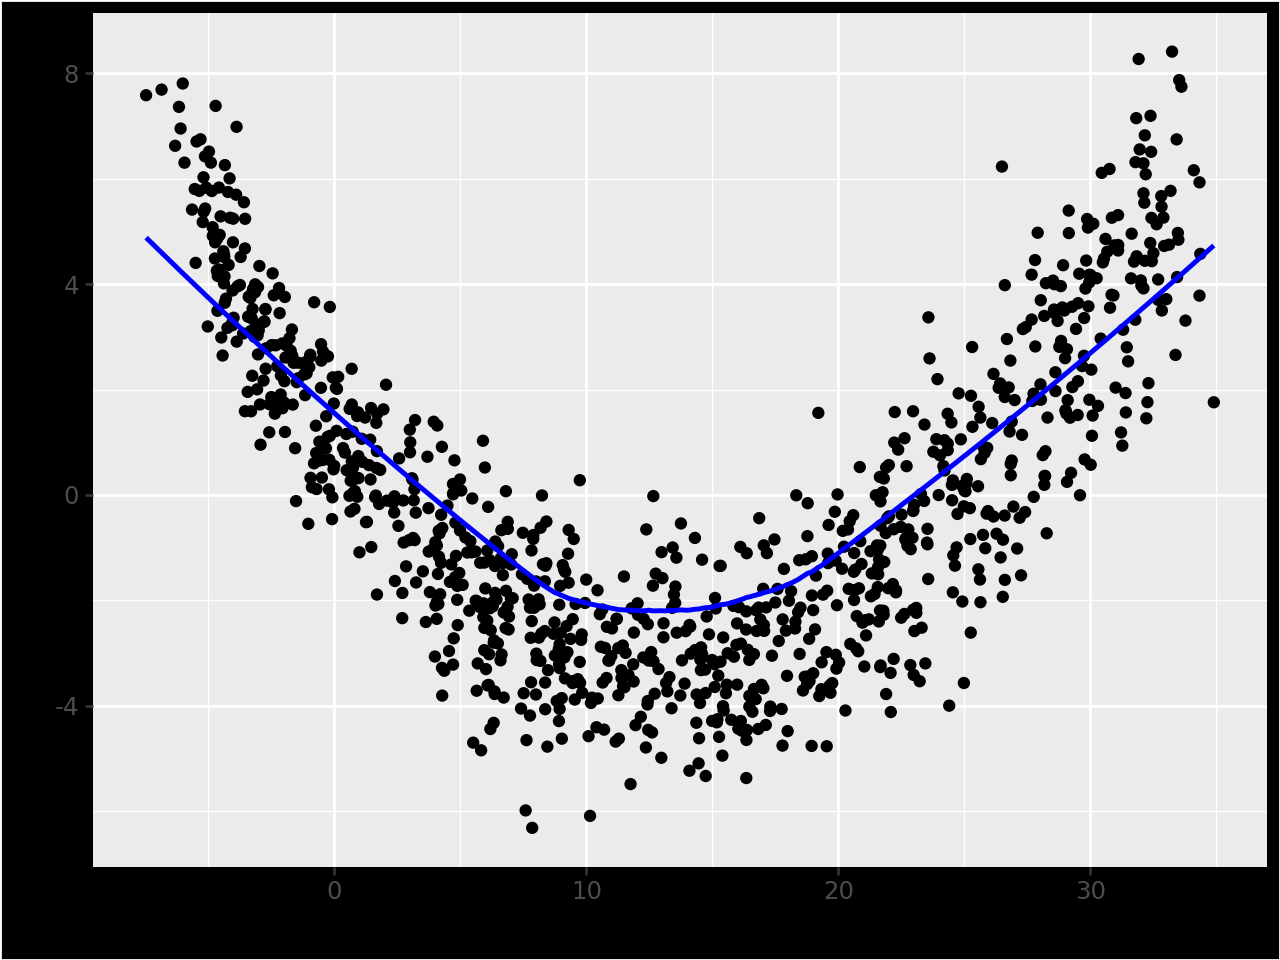

In [100]:
residuals_df = pd.DataFrame({'y_hat': fit.fittedvalues, 'residuals': fit.resid})
(ggplot(residuals_df, aes('y_hat', 'residuals'))
+ geom_point()
+ geom_smooth(method="lowess", color = 'blue'))

3. Through plotting, investigate graphically the relationship between the response variable y and the
explanatory variables x and z. Is there any transformation of the explanatory variable(s) you would
suggest?

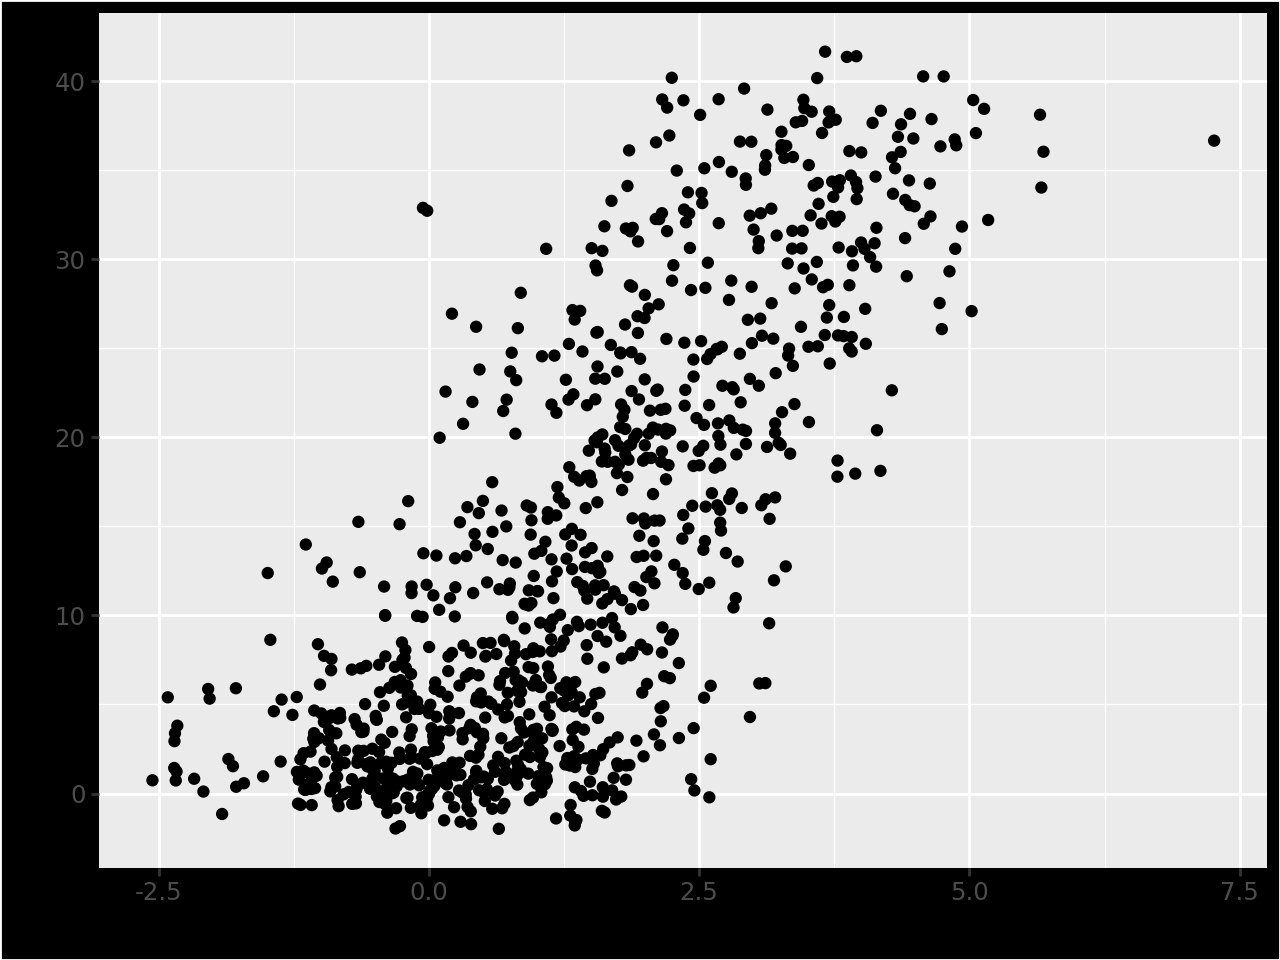

In [101]:
(ggplot(df, aes('x', 'y'))
+ geom_point())

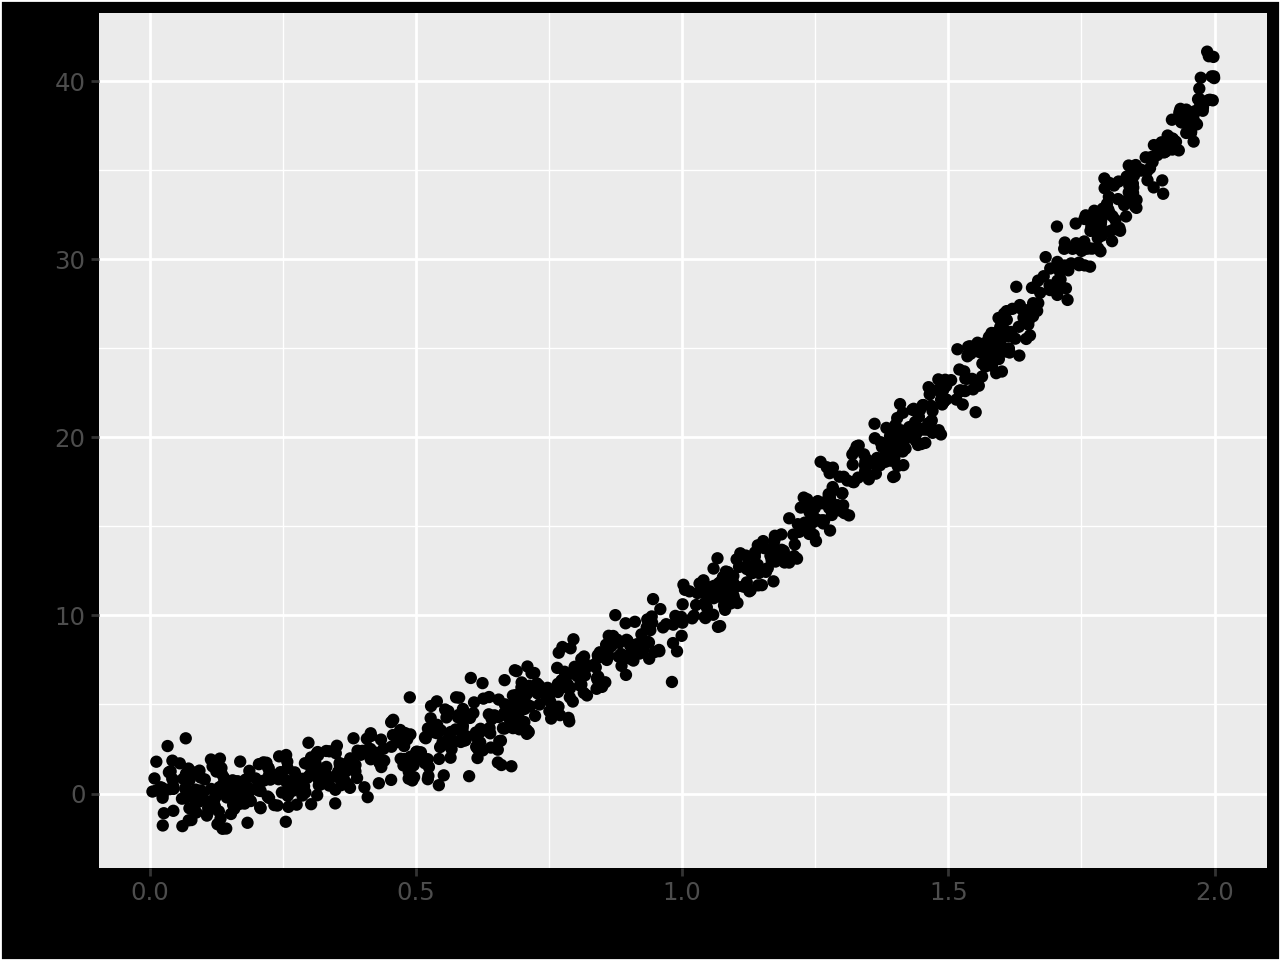

In [102]:
(ggplot(df, aes('z', 'y'))
+ geom_point())

4. Perform the linear regression against the transformed variable(s). What do you now conclude?

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


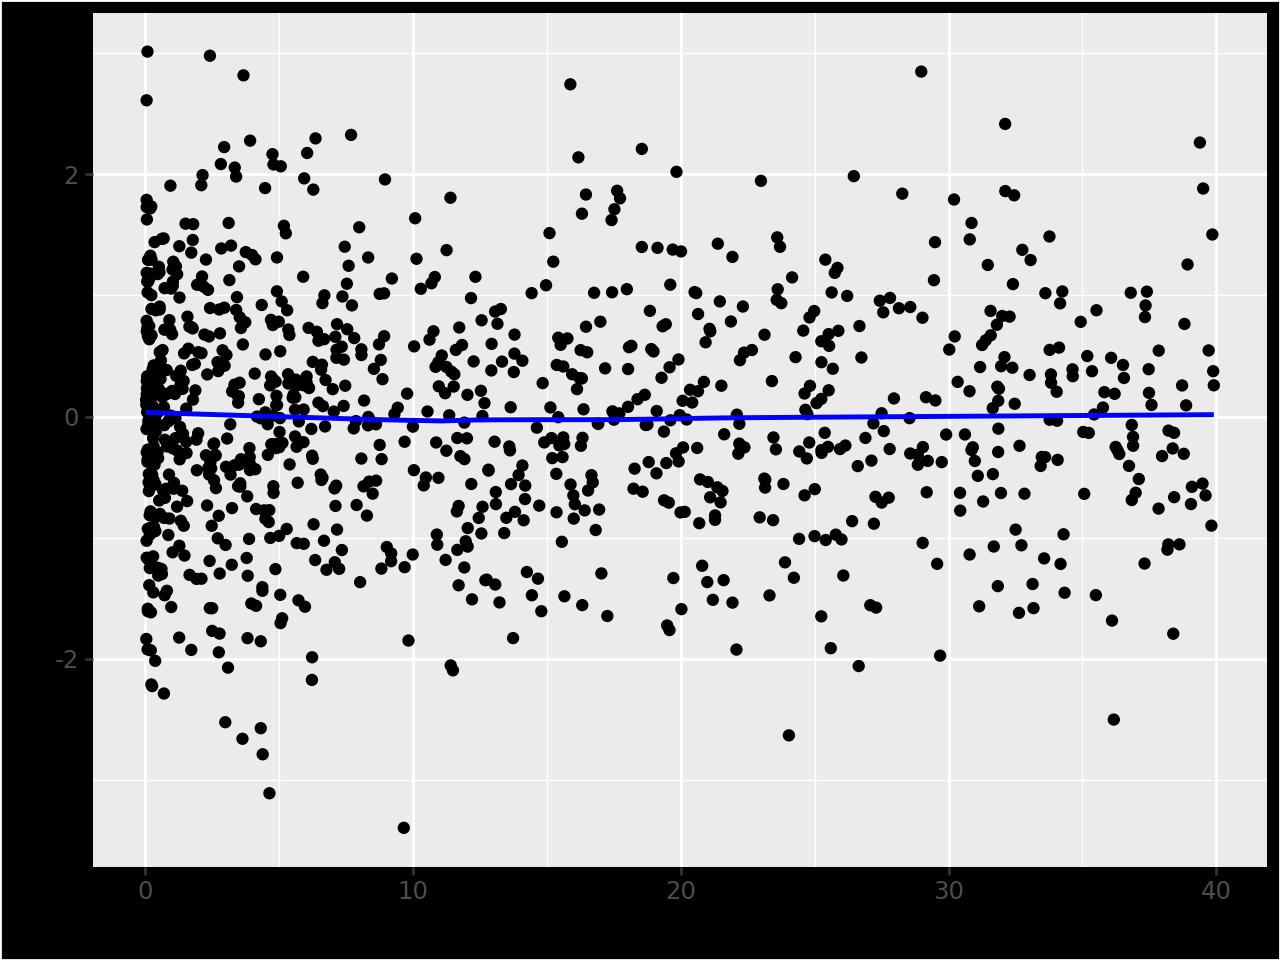

In [103]:
df['z_2'] = df['z'] ** 2
fit = smf.ols("y ~ x + z_2", data=df).fit()
residuals_df = pd.DataFrame({'y_hat': fit.fittedvalues, 'residuals': fit.resid})
(ggplot(residuals_df, aes('y_hat', 'residuals'))
+ geom_point()
+ geom_smooth(method="lowess", color = 'blue'))

# Now that we

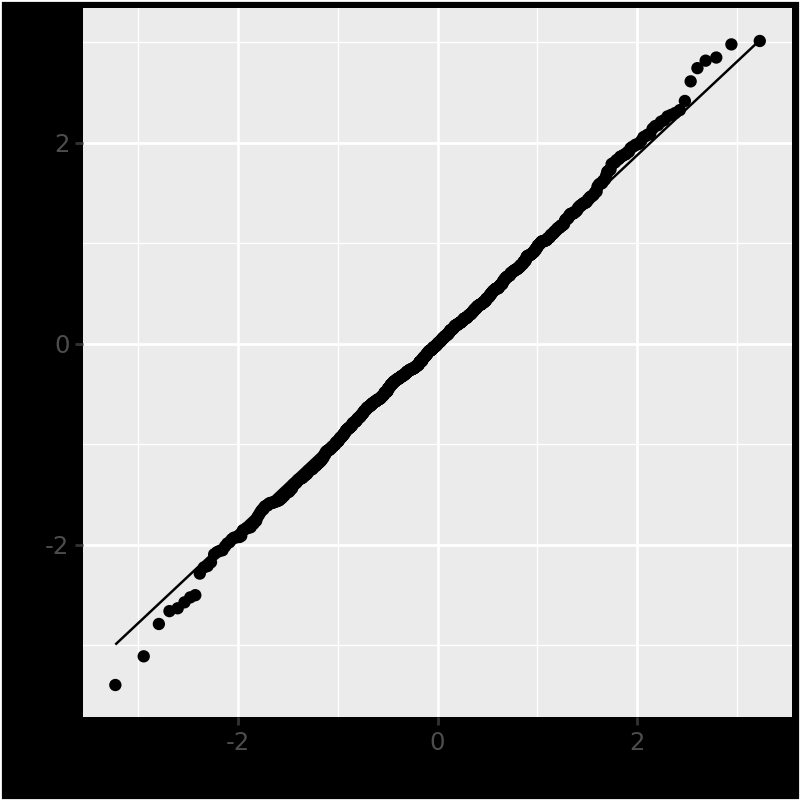

In [104]:
df_resid = pd.DataFrame({'resid': fit.resid})
(
ggplot(df_resid, aes(sample="resid"))
+ stat_qq()
+ stat_qq_line()
+ theme(figure_size=(4, 4))
)
# The residual plot does not show any non-linearity

In [105]:
fit.summary()
# the fit supports that y is linearly independent of x given z^2

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 7.562e+04
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:55:20   Log-Likelihood:                -1386.1
No. Observations:                1000   AIC:                             2778.
Df Residuals:                     997   BIC:                             2793.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0499      0.046      1.095      0.274      -0.040       0.139
x             -0.0101      0.030     -0.333      0.739      -0.070       0.050
z_2            9.9815      0.040    251.125      0.000       9.904      10.059
==============================================================================
Omnibus:                        0.973   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.615   Jarque-Bera (JB):                0.851
Skew:                           0.011   Prob(JB):                        0.654
Kurtosis:                       3.141   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Section 03 - Adjusting for confounding variables - Iris dataset
Recall the plot showing the relationship between sepal width and sepal length in the Iris dataset:

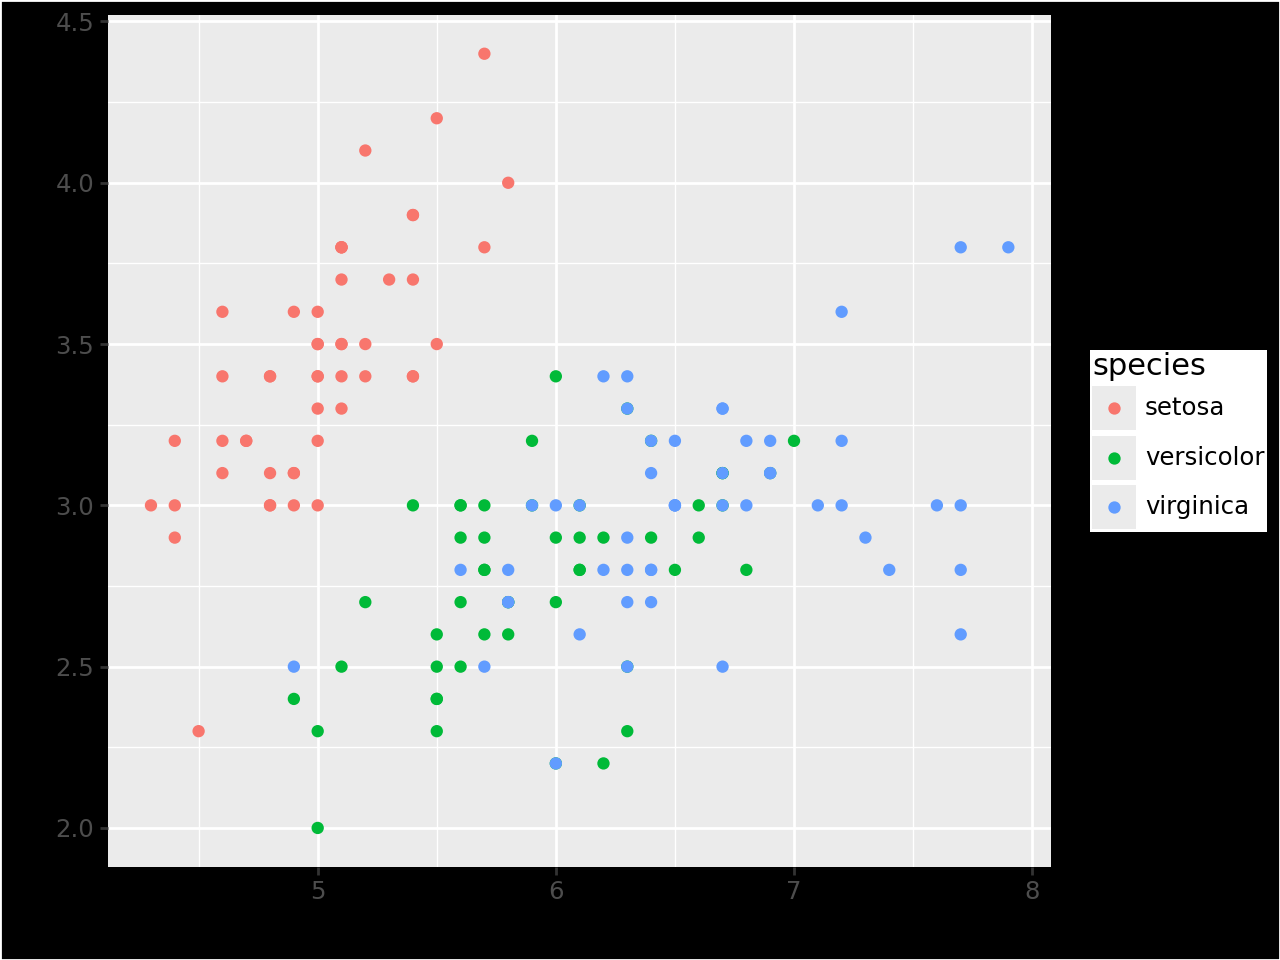

In [106]:
import seaborn as sns
iris = sns.load_dataset('iris')
(ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
geom_point()
)

1. Fit three linear models predicting Sepal.Width from Sepal.Length: the base model that simply
predicts sepal width from sepal length, one where you use the species as a covariate in linear regression
(i.e., different intercept for different species) and one where you use separate slopes and intercepts for
different species by using the * operator in sm.ols: "sepal_width ~ sepal_length * species".

In [107]:
base = smf.ols("sepal_width ~ sepal_length", data=iris).fit()
print(base.summary())
# very little seems to be explained (low R^2)

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.074
Date:                Wed, 21 Jan 2026   Prob (F-statistic):              0.152
Time:                        16:55:21   Log-Likelihood:                -86.732
No. Observations:                 150   AIC:                             177.5
Df Residuals:                     148   BIC:                             183.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4189      0.254     13.484   

In [108]:
model_species_intercept = smf.ols("sepal_width ~ sepal_length + species", data=iris).fit()
print(model_species_intercept.summary())
# a lot seems to be explained (high R^2)

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     64.32
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           1.46e-26
Time:                        16:55:21   Log-Likelihood:                -24.609
No. Observations:                 150   AIC:                             57.22
Df Residuals:                     146   BIC:                             69.26
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.67

In [109]:
model_species_intercept_slope = smf.ols("sepal_width ~ sepal_length * species", data=iris).fit()
print(model_species_intercept_slope.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     47.53
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           7.78e-29
Time:                        16:55:21   Log-Likelihood:                -14.671
No. Observations:                 150   AIC:                             41.34
Df Residuals:                     144   BIC:                             59.41
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

2. What are the slopes and intercepts of each one of the species for the model with separate slopes and
intercepts?

In [110]:
print(model_species_intercept_slope.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     47.53
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           7.78e-29
Time:                        16:55:21   Log-Likelihood:                -14.671
No. Observations:                 150   AIC:                             41.34
Df Residuals:                     144   BIC:                             59.41
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# Linear Regression with Species Indicators and Interactions
Let
- $I_{\text{virginica}}$ denote **is_virginica**
- $I_{\text{versicolor}}$ denote **is_versicolor**
where each indicator variable satisfies:
$$
I \in \{0, 1\}
$$
---
## Full Model
The linear regression model is written as:
$$
\begin{aligned}
y =\;& \beta_0
+ \beta_{\text{virginica}} \, I_{\text{virginica}}
+ \beta_{\text{versicolor}} \, I_{\text{versicolor}} \\
&+ \beta_{\text{length}} \, x \\
&+ \beta_{\text{length:virginica}} \, I_{\text{virginica}} \, x
+ \beta_{\text{length:versicolor}} \, I_{\text{versicolor}} \, x
\end{aligned}
$$
This formulation allows both the **intercept** and the **slope** to vary by species.
---

## Species-Specific Models
### Species: *Virginica*
For virginica:
$$
I_{\text{virginica}} = 1,
\qquad
I_{\text{versicolor}} = 0
$$
Substituting into the model:
$$
\begin{aligned}
y &= \beta_0
+ \beta_{\text{virginica}} \cdot 1
+ \beta_{\text{versicolor}} \cdot 0
+ \beta_{\text{length}} \, x \\
&\quad + \beta_{\text{length:virginica}} \cdot 1 \cdot x
+ \beta_{\text{length:versicolor}} \cdot 0 \cdot x
\end{aligned}
$$
which simplifies to:
$$
y = (\beta_0 + \beta_{\text{virginica}})
+ (\beta_{\text{length}} + \beta_{\text{length:virginica}})\, x
$$

**Virginica parameters:**
- **Intercept:**
  $$
  \beta_0 + \beta_{\text{virginica}}
  $$
- **Slope:**
  $$
  \beta_{\text{length}} + \beta_{\text{length:virginica}}
  $$
---

### Species: *Versicolor*
For versicolor:
$$
I_{\text{virginica}} = 0,
\qquad
I_{\text{versicolor}} = 1
$$
The model becomes:
$$
y = (\beta_0 + \beta_{\text{versicolor}})
+ (\beta_{\text{length}} + \beta_{\text{length:versicolor}})\, x
$$
**Versicolor parameters:**
- **Intercept:**
  $$
  \beta_0 + \beta_{\text{versicolor}}
  $$
- **Slope:**
  $$
  \beta_{\text{length}} + \beta_{\text{length:versicolor}}
  $$
---

### Species: *Setosa* (Reference Category)
For setosa:
$$
I_{\text{virginica}} = 0,
\qquad
I_{\text{versicolor}} = 0
$$
The model reduces to:
$$
y = \beta_0 + \beta_{\text{length}} \, x
$$
**Setosa parameters:**
- **Intercept:**
  $$
  \beta_0
  $$
- **Slope:**
  $$
  \beta_{\text{length}}
  $$
---

## Overlaying the Resulting Fits
This model produces **three distinct regression lines**:
- **Setosa:** baseline intercept and slope
- **Versicolor:** intercept and slope adjusted relative to setosa
- **Virginica:** intercept and slope adjusted relative to setosa
Overlaying these fitted lines on the same scatter plot allows direct visual comparison of how the relationship between $x$ and $y$ differs by species.

3. Overlay the resulting fits of each model on the scatterplot above (Hint: use predict to generate
predictions)

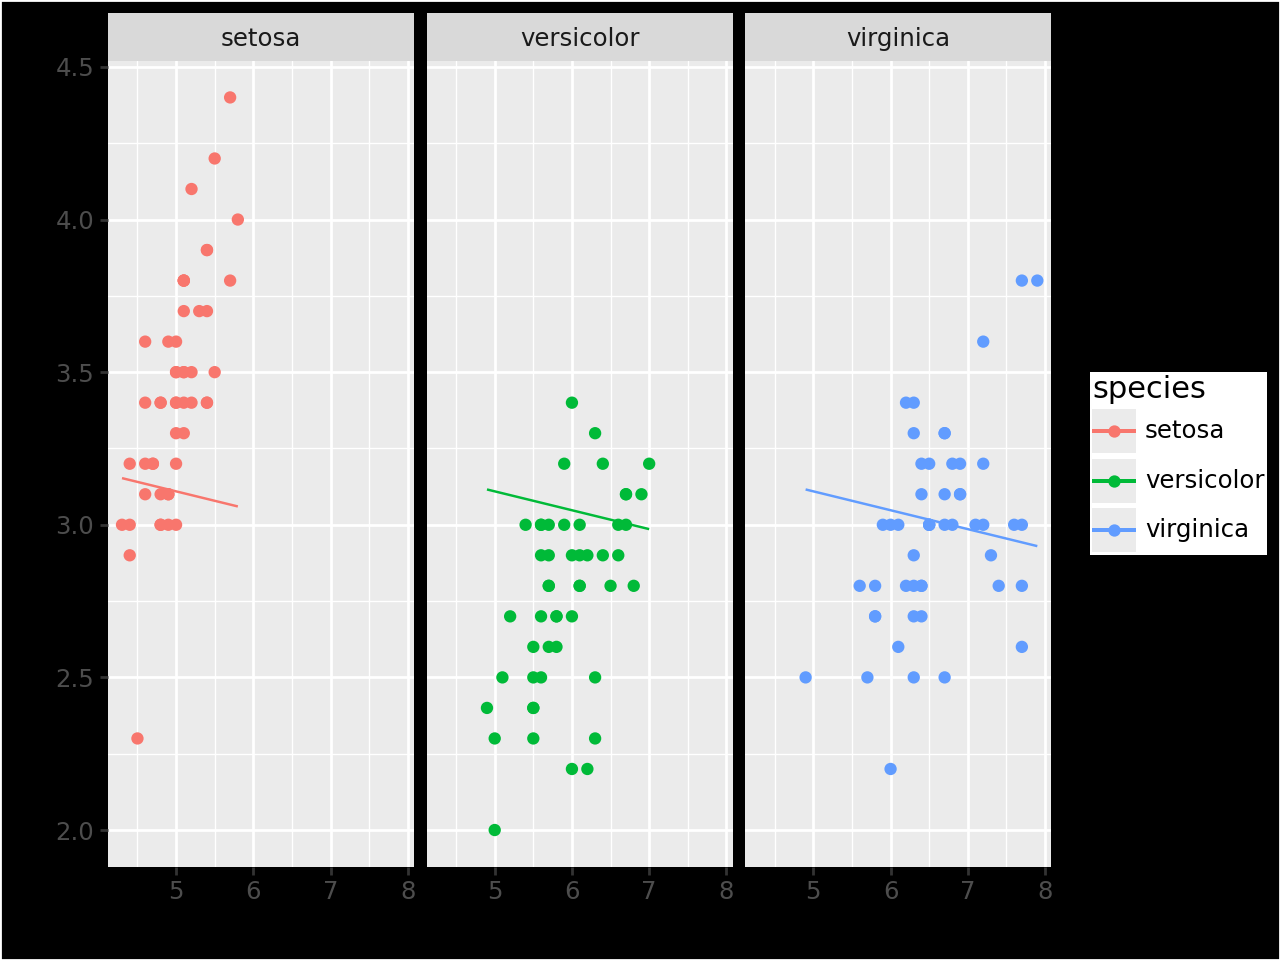

In [111]:
iris['base_predictions'] = base.predict(iris)
(ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
geom_point() +
geom_line(iris, aes(x = 'sepal_length', y = 'base_predictions')) +
facet_wrap('species')
)

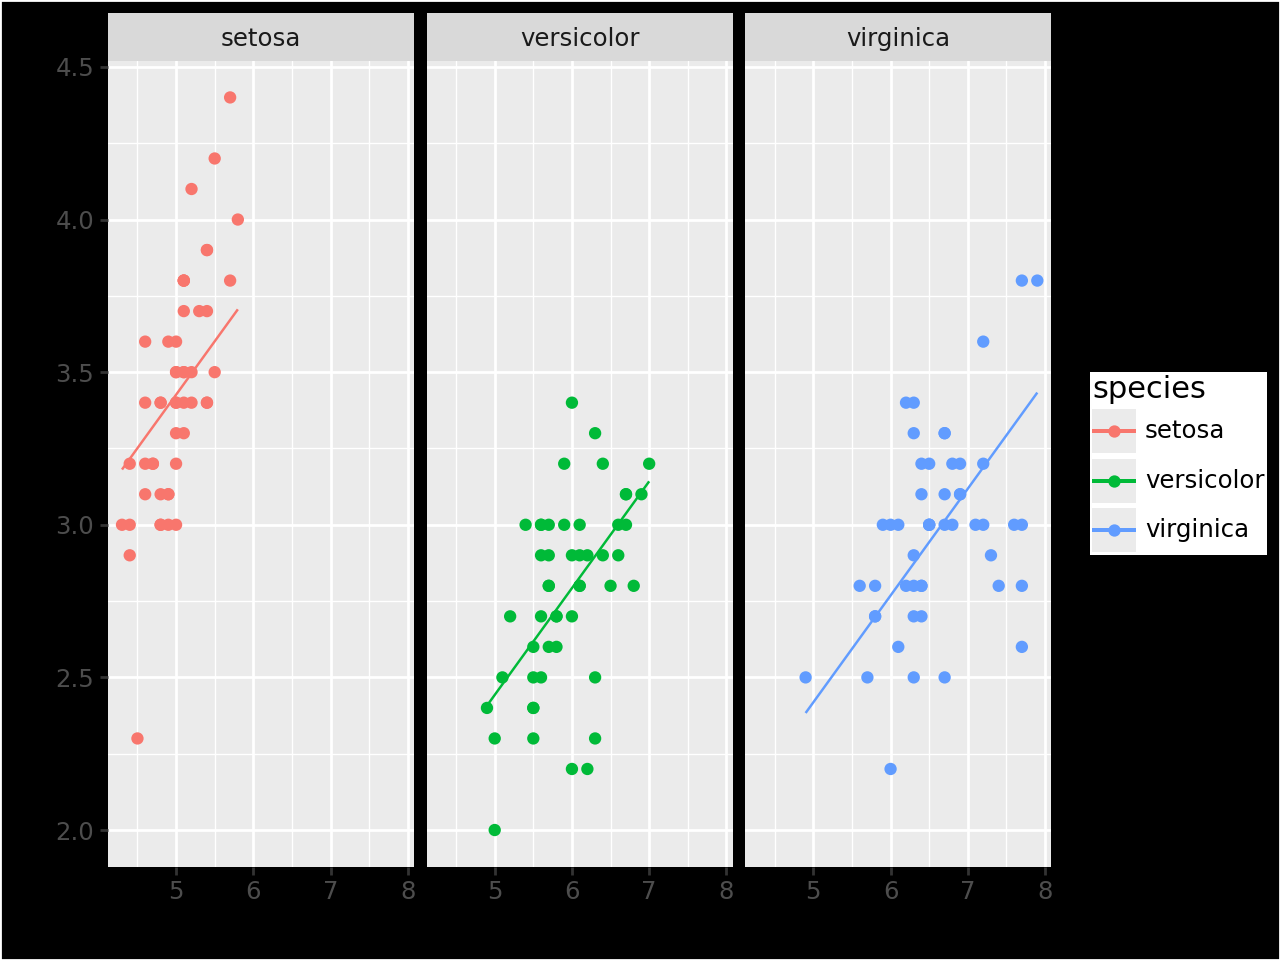

In [112]:
iris['species_intercept_predictions'] = model_species_intercept.predict(iris)
(ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
geom_point() +
geom_line(iris, aes(x = 'sepal_length', y = 'species_intercept_predictions')) +
facet_wrap('species')
)

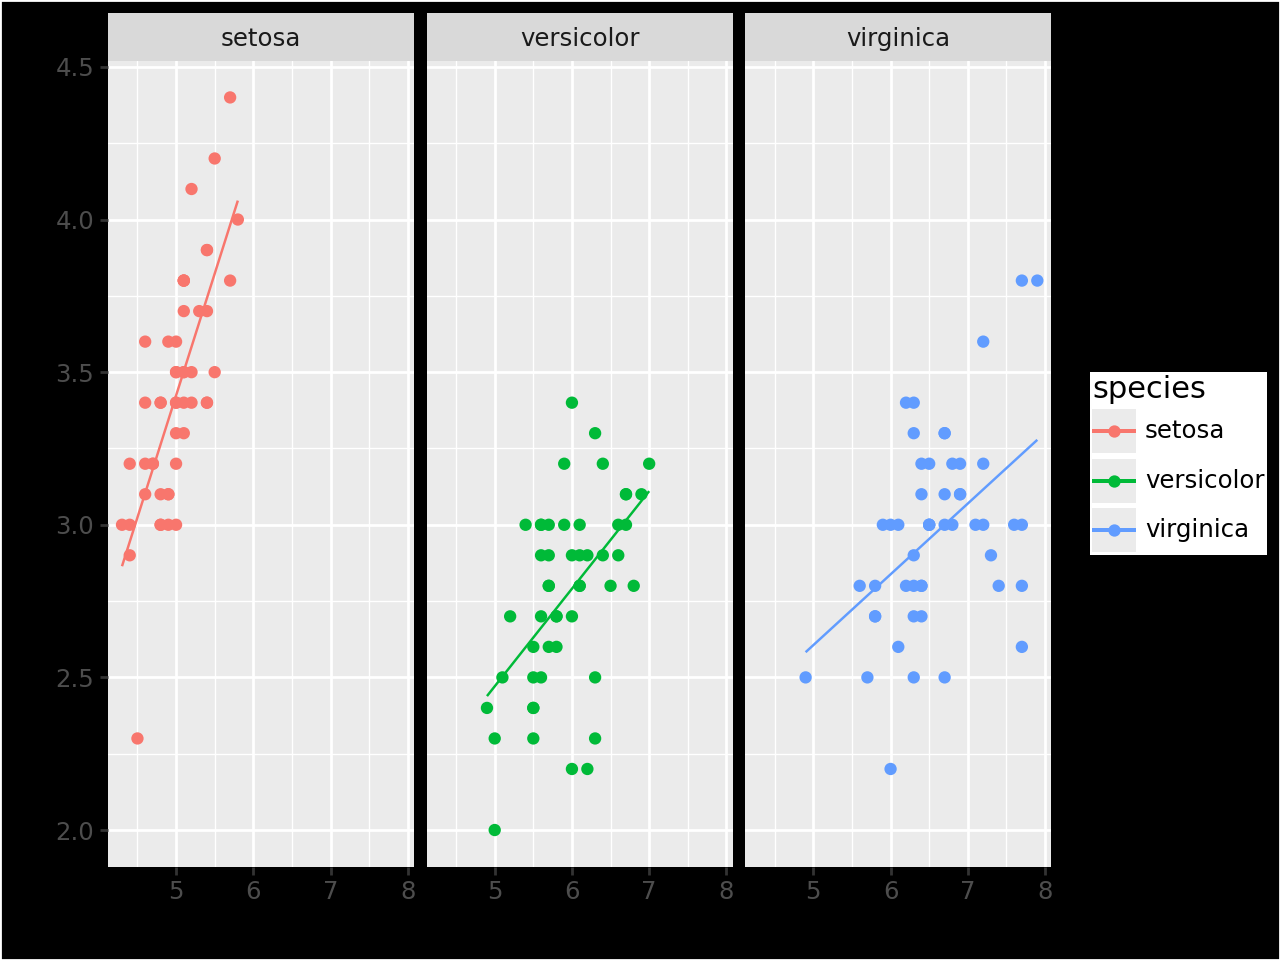

In [113]:
iris['species_intercept_slope_predictions'] = model_species_intercept_slope.predict(iris)
(ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
geom_point() +
geom_line(iris, aes(x = 'sepal_length', y = 'species_intercept_slope_predictions')) +
facet_wrap('species')
)

4. Use anova to test if the second model is a better model than the base and also if the third model is
better than the second. Suppose all the assumptions of linear regression hold.

In [114]:
anova_results = anova_lm(base, model_species_intercept)
print(anova_results)

   df_resid        ssr  df_diff    ss_diff          F        Pr(>F)
0     148.0  27.915656      0.0        NaN        NaN           NaN
1     146.0  12.193134      2.0  15.722522  94.130364  5.489434e-27


In [115]:
# Ho: adding species info does not improve the model
# Conclusion: F statistic is big, p value > 0.05, we reject Ho. Therefore, adding species info does improve the model.

# Now for the second vs third model
anova_results = anova_lm(model_species_intercept, model_species_intercept_slope)
print(anova_results)
# Ho: modelling the petal length independently does not improve the model
# Conclusion: F value is big, p value > 0.05, we reject Ho

   df_resid        ssr  df_diff   ss_diff          F    Pr(>F)
0     146.0  12.193134      0.0       NaN        NaN       NaN
1     144.0  10.679969      2.0  1.513165  10.201145  0.000072
